## Prediction results analysis

In [18]:
import pandas as pd
import shap
from pathlib import Path
import os
import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import torchvision.models as models
import random
import matplotlib.pyplot as plt

In [19]:
results_csv = 'detailed_predictions.csv'
#Reading the prediction file
df = pd.read_csv(results_csv)
print(df.head())

                      filename  true_label  predicted_label  prob_drunk  \
0  0061006001_h_00.wav_0_1.jpg         1.0              1.0    0.787337   
1  0061006002_h_00.wav_0_1.jpg         1.0              1.0    0.987181   
2  0061006002_h_00.wav_1_1.jpg         1.0              0.0    0.007271   
3  0061006002_h_00.wav_2_1.jpg         1.0              0.0    0.353910   
4  0061006002_h_00.wav_3_1.jpg         1.0              1.0    0.986333   

   prob_sober  correct  
0    0.212663     True  
1    0.012819     True  
2    0.992729    False  
3    0.646090    False  
4    0.013667     True  


In [20]:
def get_task_set(filename):
    recording_name = filename.split('_')[0]
    session_number = recording_name[-7:-3]
    task_id = recording_name[-3:]
    block_number = session_number[0]

    if block_number == '1' or block_number == '3':
        task_set = 'DRUNK'
    else:
        task_set = 'SOBER'

    return task_set, task_id

task_sets,tasks_id = [],[]
for index, row in df.iterrows():
    #print(row)
    task_set, task_id = get_task_set(row[0])
    task_sets.append(task_set)
    tasks_id.append(task_id)

df['task_set'] = task_sets
df['task_id'] = tasks_id



C:\Users\nagap\AppData\Local\Temp\ipykernel_9728\2006022529.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  task_set, task_id = get_task_set(row[0])


In [21]:
task_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\DrunkenLinguists\inebriation-voice-detector")
taskmap_file = os.path.join(task_folder, 'TaskACL.xlsx')

drunk_tasks = pd.read_excel(taskmap_file, sheet_name='Drunk tasks',dtype={'Drunk task ID': str,'Sober task ID': str, 'Merge task ID': str})
sober_tasks = pd.read_excel(taskmap_file, sheet_name='Sober tasks',dtype={'Drunk task ID': str,'Sober task ID': str, 'Merge task ID': str})

#Changig column names
drunk_tasks = drunk_tasks.rename(columns={
    'Drunk task ID': 'Task ID',
    'Merge task ID': 'Merge ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})

sober_tasks = sober_tasks.rename(columns={
    'Sober task ID': 'Task ID',
    'Merge task ID': 'Merge ID',
    'Type': 'Type',
    'Subtype': 'Subtype'
})

# Combine task metadata: task ID (Merge Task ID), type, and subtype
task_metadata = pd.concat([drunk_tasks[['Merge ID', 'Type', 'Subtype']],
                           sober_tasks[['Merge ID', 'Type', 'Subtype']]]).drop_duplicates(subset=["Merge ID"])
    
#Creating mapping dictionaries
drunk_map = dict(zip(drunk_tasks['Task ID'], drunk_tasks['Merge ID']))
sober_map = dict(zip(sober_tasks['Task ID'], sober_tasks['Merge ID']))

#Function to apply correct mapping acordinng to task set
def map_merge_id(row):
    if row["task_set"] == 'DRUNK':
        return drunk_map.get(row["task_id"])
    elif row["task_set"] == 'SOBER':
        return sober_map.get(row["task_id"])
    else:
        return None
        
df['Merge ID'] = df.apply(map_merge_id, axis=1)

#Merge with task metadata
merged_df = df.merge(task_metadata, on='Merge ID', how='left')


In [22]:
#4045 total 2023 DRUNK 2022 SOBER
#Counting total
type_counts = merged_df.groupby(['Subtype','true_label']).size().reset_index(name='Count')
type_counts.sort_values(by=['Subtype'])
pivot_type_counts = type_counts.pivot_table(index='Subtype', columns='true_label', values='Count', 
                                            fill_value=0).reset_index()

# Rename columns for clarity (if needed)
pivot_type_counts.columns.name = None  # Remove the columns' name if present
pivot_type_counts = pivot_type_counts.rename(columns={0.0: 'SOBER', 1.0: 'DRUNK'})
print(pivot_type_counts)



                  Subtype  SOBER  DRUNK
0       Describe an image  580.0  487.0
1         Issue a command  256.0  211.0
2         Rapid word list  108.0   95.0
3          Read a command  101.0   92.0
4    Read a license plate   54.0   46.0
5           Read a number  216.0  184.0
6      Read a temperature   52.0   43.0
7   Read a tongue twister  162.0  140.0
8         Read an address  269.0  231.0
9            Spell a word   54.0   48.0
10           Tell a story  335.0  281.0


In [23]:
# Inspecting correct/incorrect predictions by subtype
type_counts = merged_df.groupby(['Subtype', 'correct']).size().reset_index(name='Count')

# Pivot to get correct/incorrect counts side by side
pivot_type_counts = type_counts.pivot_table(
    index='Subtype', 
    columns='correct', 
    values='Count', 
    fill_value=0
).reset_index()

# Rename columns for clarity (if needed)
pivot_type_counts.columns.name = None  # Remove the columns' name if present
pivot_type_counts = pivot_type_counts.rename(columns={False: 'Incorrect', True: 'Correct'})

# Add a total column and sort by it
pivot_type_counts['Total'] = pivot_type_counts['Correct'] + pivot_type_counts['Incorrect']
pivot_type_counts['% Incorrect'] = pivot_type_counts['Incorrect']/pivot_type_counts['Total']
pivot_type_counts['% Correct'] = 1-pivot_type_counts['Incorrect']/pivot_type_counts['Total']
pivot_type_counts = pivot_type_counts.sort_values(by='% Incorrect', ascending=False)

print(pivot_type_counts)


                  Subtype  Incorrect  Correct   Total  % Incorrect  % Correct
9            Spell a word       45.0     57.0   102.0     0.441176   0.558824
8         Read an address      197.0    303.0   500.0     0.394000   0.606000
5           Read a number      157.0    243.0   400.0     0.392500   0.607500
4    Read a license plate       39.0     61.0   100.0     0.390000   0.610000
10           Tell a story      240.0    376.0   616.0     0.389610   0.610390
0       Describe an image      397.0    670.0  1067.0     0.372071   0.627929
3          Read a command       69.0    124.0   193.0     0.357513   0.642487
2         Rapid word list       72.0    131.0   203.0     0.354680   0.645320
1         Issue a command      164.0    303.0   467.0     0.351178   0.648822
7   Read a tongue twister      105.0    197.0   302.0     0.347682   0.652318
6      Read a temperature       31.0     64.0    95.0     0.326316   0.673684


In [53]:
# Inspecting correct/incorrect predictions by Merge ID
type_counts = merged_df.groupby(['Subtype','Merge ID', 'correct']).size().reset_index(name='Count')

# Pivot to get correct/incorrect counts side by side
pivot_type_counts = type_counts.pivot_table(
    index=['Subtype','Merge ID'], 
    columns='correct', 
    values='Count', 
    fill_value=0
).reset_index()

# Rename columns for clarity (if needed)
pivot_type_counts.columns.name = None  # Remove the columns' name if present
pivot_type_counts = pivot_type_counts.rename(columns={False: 'Incorrect', True: 'Correct'})

# Add a total column and sort by it
pivot_type_counts['Total'] = pivot_type_counts['Correct'] + pivot_type_counts['Incorrect']
pivot_type_counts['% Incorrect'] = pivot_type_counts['Incorrect']/pivot_type_counts['Total']
pivot_type_counts = pivot_type_counts.sort_values(by='% Incorrect', ascending=False)

print(pivot_type_counts)

# Create a prioritized list of Merge IDs based on % Incorrect (highest first)
priority_merge_ids = pivot_type_counts['Merge ID'].tolist()
priority_merge_ids_df = pd.DataFrame({'Merge ID':priority_merge_ids})
priority_merge_ids_df.to_csv('priority_merge_ids.csv',index=False)

                  Subtype Merge ID  Incorrect  Correct  Total  % Incorrect
23        Read an address      008       50.0     50.0  100.0     0.500000
16          Read a number      026       45.0     55.0  100.0     0.450000
28           Spell a word      060       45.0     57.0  102.0     0.441176
21  Read a tongue twister      036       44.0     56.0  100.0     0.440000
26        Read an address      024       42.0     58.0  100.0     0.420000
14          Read a number      001       41.0     59.0  100.0     0.410000
9         Rapid word list      032       40.0     61.0  101.0     0.396040
29           Tell a story      014       79.0    122.0  201.0     0.393035
6         Issue a command      049       38.0     59.0   97.0     0.391753
13   Read a license plate      031       39.0     61.0  100.0     0.390000
2       Describe an image      038      125.0    197.0  322.0     0.388199
30           Tell a story      034      161.0    254.0  415.0     0.387952
25        Read an address

In [25]:
#Inspecting incorrect predictions
correct_df = merged_df[merged_df['correct'] == False]
type_counts = correct_df.groupby(['Merge ID','Subtype','true_label']).size().reset_index(name='Count')
type_counts.sort_values(by=['Merge ID'])
pivot_type_counts = type_counts.pivot_table(index=['Merge ID','Subtype'], columns='true_label', values='Count', 
                                            fill_value=0).reset_index()
print(pivot_type_counts)

true_label Merge ID                Subtype   0.0   1.0
0               001          Read a number  27.0  14.0
1               004        Read an address  18.0   0.0
2               008        Read an address  35.0  15.0
3               010      Describe an image  62.0  77.0
4               012        Rapid word list  15.0  17.0
5               013        Read an address  29.0   9.0
6               014           Tell a story  32.0  47.0
7               015          Read a number  19.0  17.0
8               019        Read an address  34.0   5.0
9               020  Read a tongue twister  30.0   7.0
10              023  Read a tongue twister  10.0  14.0
11              024        Read an address  34.0   8.0
12              026          Read a number  32.0  13.0
13              029          Read a number  19.0  16.0
14              030      Describe an image  56.0  77.0
15              031   Read a license plate  31.0   8.0
16              032        Rapid word list  27.0  13.0
17        

In [ ]:
model_folder = Path(r"C:\Users\nagap\Downloads")
model_file = os.path.join(model_folder, 'best_model.pth')
list_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC")
image_folder = Path(r"C:\Users\nagap\OneDrive\Documentos\Maestria\2025S\Phonetics TeamLab\ALC\TRAIN\TRAIN")
spect_csv = os.path.join(list_folder, 'spectrogram_listTrainfixed.csv')

# Load your CSV with spectrogram metadata
df = pd.read_csv(spect_csv)

# Randomly sample N filenames (e.g., 100)
sampled_df = df.sample(n=100, random_state=42)
file_list = sampled_df[['spectrogram_fileP','label']].values.tolist()

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def load_images(rows,folder):
    images = []
    for fname,label in rows:
        subfolder = 'SOBER' if label == 0 else 'DRUNK'
        path = os.path.join(folder, subfolder, fname)
        img = Image.open(path).convert("RGB")
        images.append(transform(img))
    return torch.stack(images)

def resnet18_classifier():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze deeper layers for fine-tuning
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace classifier head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)  # Output for binary classification
    )

    return model.to(device)

# Load the sampled images
X_sample = load_images(file_list,image_folder)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = resnet18_classifier()

# Step 3: Load the saved weights
model.load_state_dict(torch.load(model_file, map_location=device))
model.eval()
model = model.to(device)

X_sample = X_sample.to(device)

background = X_sample[:20]  
test_images = X_sample[:10]
explainer = shap.GradientExplainer(model, background)

# Compute SHAP values for your test images
shap_values = explainer(test_images)  # this returns a shap.Explanation object

# Visualize
#shap.image_plot(shap_values)

C:\Users\nagap\AppData\Local\Temp\ipykernel_9728\709267319.py:60: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file, map_location=dev

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].


(10, 3, 224, 224, 1)
(10, 224, 224, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.42

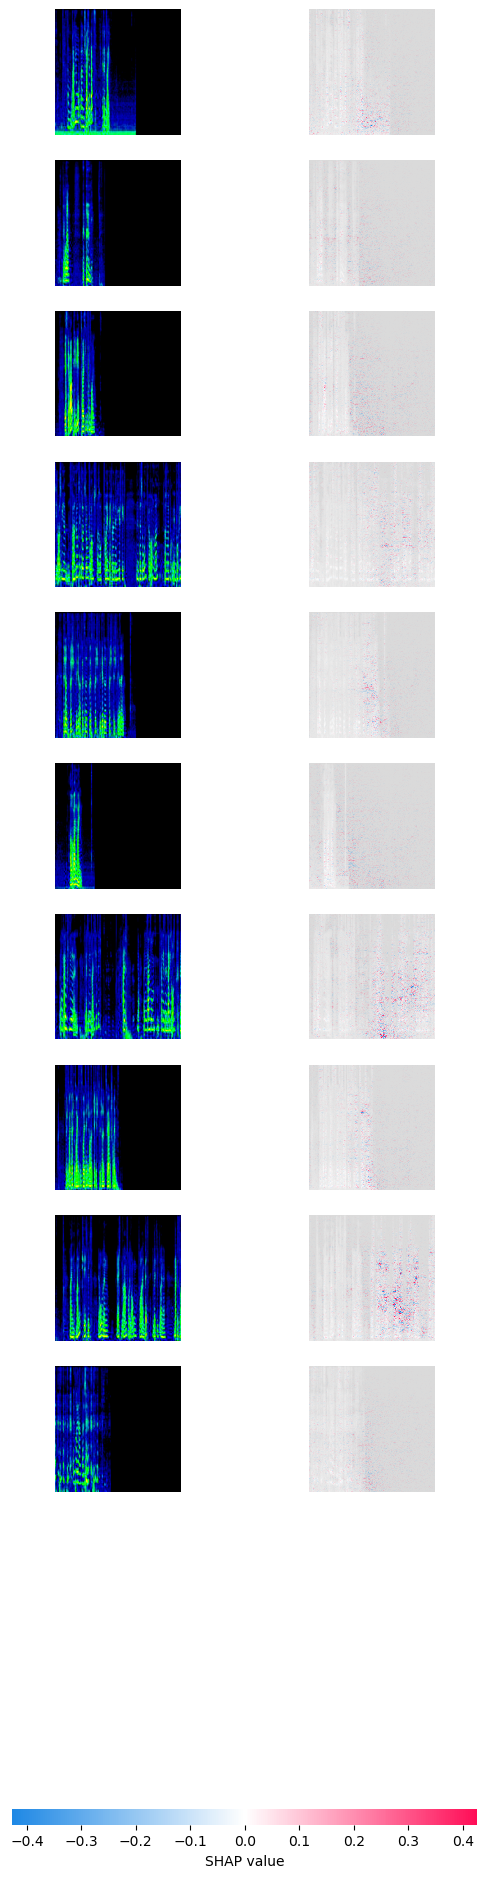

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.42

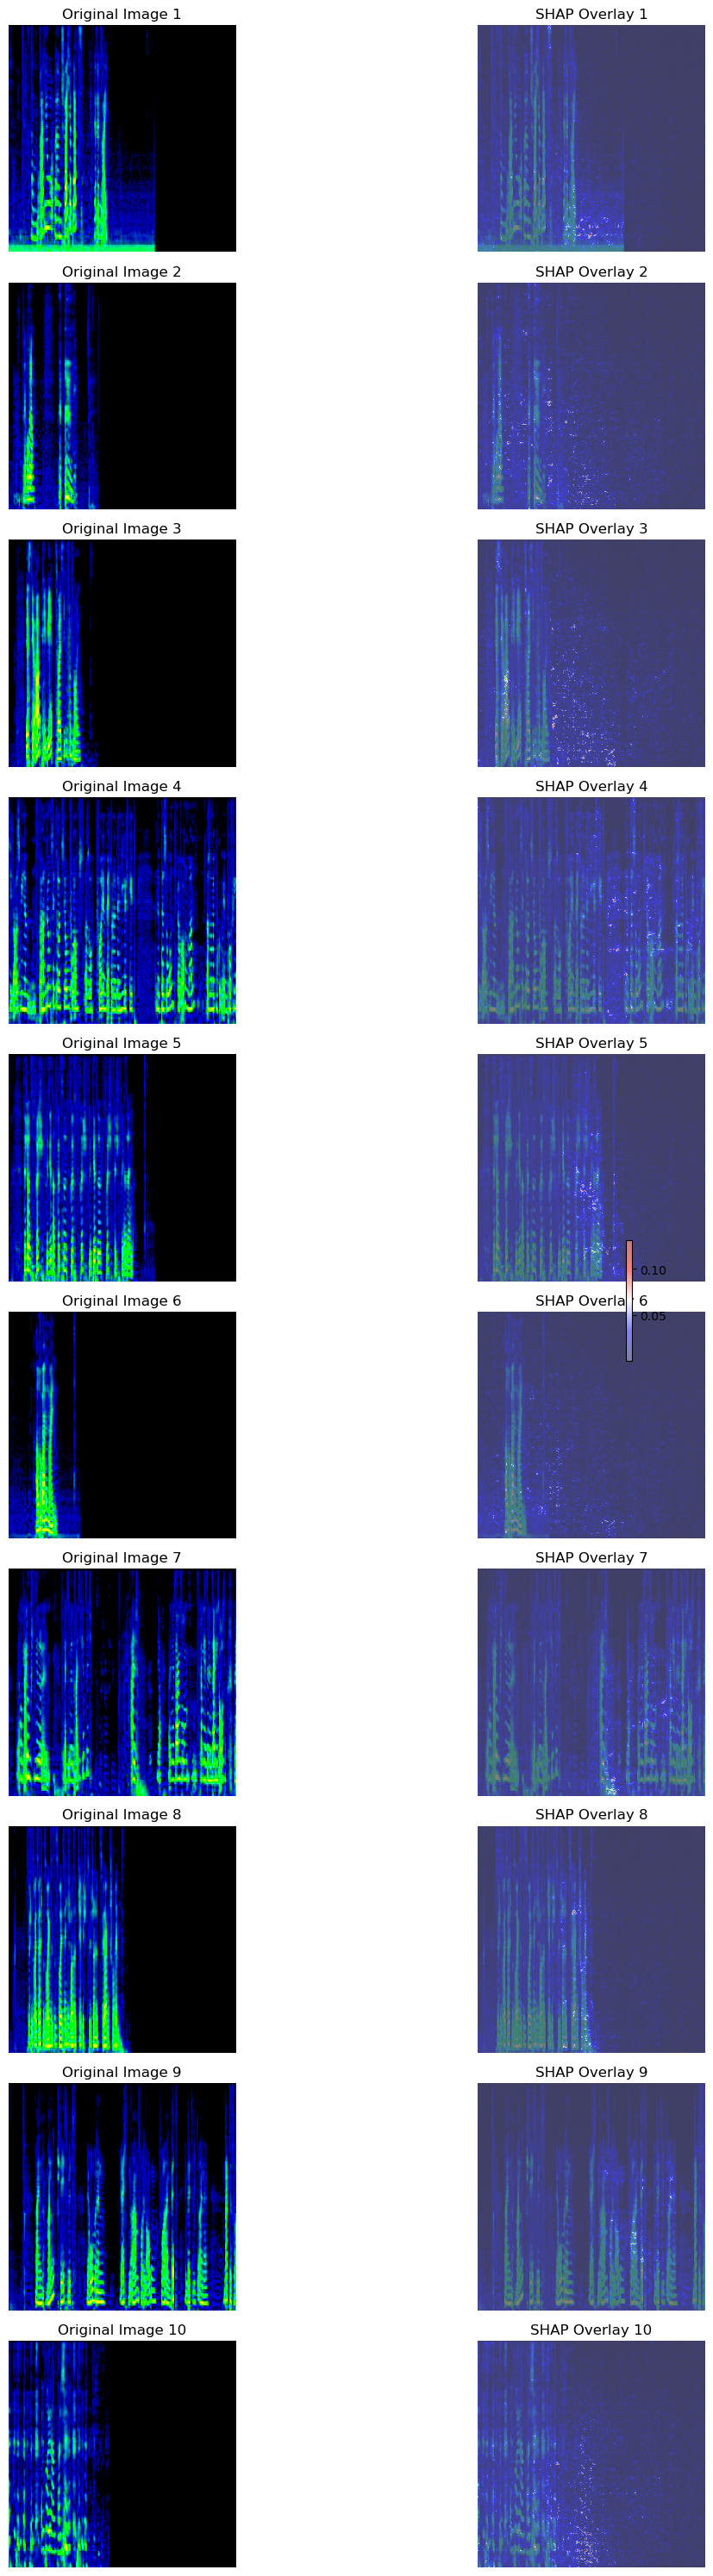

In [51]:
# Check shape of SHAP values
print(np.array(shap_values.values).shape)
images_np = test_images.cpu().numpy().transpose(0, 2, 3, 1)
num_images = images_np.shape[0]
# Convert SHAP values to numpy and transpose to expected shape
# (C, H, W, 1) → (H, W, C)
shap_values_np = shap_values.values  # Shape: (10, 3, 224, 224, 1)
shap_values_corrected = np.transpose(shap_values_np, (0, 2, 3, 1, 4))  # (10, 224, 224, 3, 1)
shap_values_corrected = np.squeeze(shap_values_corrected, -1)  # (10, 224, 224, 3)
shap_vals = np.squeeze(shap_values_np,axis = -1)

print(shap_values_corrected.shape)
# Now use image_plot
shap.image_plot([shap_values_corrected], images_np)


fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 3))

if num_images == 1:
    axes = np.expand_dims(axes, axis=0)
for i in range(num_images):
    orig_img = images_np[i]

    # Safely compute SHAP overlay
    shap_img = shap_vals[i]
    if shap_img.ndim == 3:
        shap_img = np.abs(shap_img).mean(axis=0)  # shape (224, 224)
    elif shap_img.ndim == 2:
        shap_img = np.abs(shap_img)
    else:
        raise ValueError(f"Unexpected SHAP image shape: {shap_img.shape}")

    # Plot original
    axes[i, 0].imshow(orig_img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"Original Image {i+1}")

    # Plot SHAP overlay
    axes[i, 1].imshow(orig_img, alpha=0.5)
    im = axes[i, 1].imshow(shap_img, cmap='seismic', alpha=0.5)
    axes[i, 1].axis('off')
    axes[i, 1].set_title(f"SHAP Overlay {i+1}")

# Colorbar for SHAP scale
fig.colorbar(im, ax=axes[:, 1], fraction=0.02, pad=0.02)

plt.tight_layout()
plt.show()